# P01 (basic) — homogeneous transformations & ray-casting selection

**Module 19 — 3D User Interfaces**

Every 3D interaction stands and falls with two building blocks:
1. **Coordinate transformations** — an object exists in several frames of reference at the same
   time (object / world / camera), and interaction means constantly converting between them.
2. **Ray-casting** — the most common selection technique: a virtual ray from the controller,
   and the **first object hit** is selected.

In this project you build both from scratch: the **4x4 transformation matrices** (and you see
why homogeneous coordinates are needed) and the **ray-sphere intersection mathematics** with
which you select in a scene by a ray.

### Goal
After this project you can …
- build homogeneous 4x4 matrices for translation/rotation/scaling and **chain** them,
- send points through the transformation chain object->world and **invert** the chain,
- derive and implement the **ray-sphere intersection equation**,
- select in a 3D scene by ray-casting (the nearest hit) and visualize it.

### Format
A Jupyter notebook — 3D geometry lives off numbers + visualization side by side.

### Prior knowledge
Linear algebra (matrix x vector, the dot product). Chapters 3 & 5 of the module 19 script.
The rotation mathematics from module 17 (quaternions -> a rotation matrix) reappears here.

### Tasks
Most cells are given; at the `# TODO` places you fill in the core building blocks.
**This is the complete solution.**


## Setup
We use `numpy` (mathematics) and `matplotlib` (the 3D plot). Both are in the `.venv`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (activates the 3D projection)
np.set_printoptions(precision=3, suppress=True)


## Part A — homogeneous 4x4 transformations

A 3D point $\mathbf{p}=(x,y,z)$ is written **homogeneously** as $(x,y,z,1)$. The reason
(script, ch. 3): **translation is not a linear map** and can only be written as a matrix this
way — then rotation, translation and scaling are **all** 4x4 matrices and **chainable**.

$$T(\mathbf t)=\begin{pmatrix}1&0&0&t_x\\0&1&0&t_y\\0&0&1&t_z\\0&0&0&1\end{pmatrix},\quad
S(\mathbf s)=\mathrm{diag}(s_x,s_y,s_z,1),\quad
R=\begin{pmatrix}\mathbf R_{3\times3}&\mathbf 0\\\mathbf 0^\top&1\end{pmatrix}$$

**Your task:** fill in the translation and the scaling matrix. `rotation_matrix` (from an axis +
an angle, via Rodrigues) is given.


In [2]:
def translation(t):
    # the 4x4 translation matrix for the vector t=(tx,ty,tz)
    M = np.eye(4)
    M[:3, 3] = np.asarray(t, float)
    return M

def scaling(s):
    # the 4x4 scaling matrix for s=(sx,sy,sz)
    M = np.eye(4)
    M[0, 0], M[1, 1], M[2, 2] = s
    return M

def rotation_matrix(axis, angle_deg):
    # The Rodrigues formula: a 3x3 rotation about an (arbitrary) axis, embedded in 4x4. [given]
    axis = np.asarray(axis, float); axis = axis / np.linalg.norm(axis)
    th = np.deg2rad(angle_deg)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    R3 = np.eye(3) + np.sin(th) * K + (1 - np.cos(th)) * (K @ K)
    M = np.eye(4); M[:3, :3] = R3
    return M

def to_homogeneous(pts):
    # (N,3) -> (N,4) with w=1   [given]
    pts = np.atleast_2d(pts)
    return np.hstack([pts, np.ones((pts.shape[0], 1))])

def from_homogeneous(pts_h):
    # (N,4) -> (N,3), divides by w   [given]
    return pts_h[:, :3] / pts_h[:, 3:4]

# A test: chain first scaling, then rotating (90 deg about z), then translating
M = translation([1, 2, 3]) @ rotation_matrix([0, 0, 1], 90) @ scaling([2, 2, 2])
p = np.array([[1, 0, 0]])
p_out = from_homogeneous((M @ to_homogeneous(p).T).T)
print("the transformed point:", p_out[0])


the transformed point: [1. 4. 3.]


**Expectation / self-check.** The point $(1,0,0)$ gets: scaled ->$(2,0,0)$, rotated by 90 degrees
about z ->$(0,2,0)$, translated by $(1,2,3)$ -> **$(1,4,3)$**. Does that come out?

Note: `translation @ rotation @ scaling` is applied **from right to left** — the scaling first.
Swap the order and you get something different (matrix multiplication is **not commutative** —
like the rotations in module 17).


## Part B — the transformation chain and its inverse

An object (in local coordinates) sits in the world via a **model matrix** $M$. Conversely you
compute world coordinates back into the object with $M^{-1}$. For a rigid transformation
(rotation + translation) the closed form holds (script, ch. 3):

$$M=\begin{pmatrix}\mathbf R&\mathbf t\\\mathbf 0^\top&1\end{pmatrix},\qquad
  M^{-1}=\begin{pmatrix}\mathbf R^\top&-\mathbf R^\top\mathbf t\\\mathbf 0^\top&1\end{pmatrix}$$

(it uses $\mathbf R^{-1}=\mathbf R^\top$, because rotation matrices are orthogonal — no numerical
inversion needed).

**Your task:** implement `rigid_inverse(M)` with this formula (not `np.linalg.inv`!).


In [3]:
def rigid_inverse(M):
    R = M[:3, :3]
    t = M[:3, 3]
    Minv = np.eye(4)
    Minv[:3, :3] = R.T
    Minv[:3, 3] = -R.T @ t
    return Minv

# Verification against np.linalg.inv (only as a check)
M = translation([1, 2, 3]) @ rotation_matrix([1, 1, 0], 37)
Minv = rigid_inverse(M)
print("max deviation from np.linalg.inv:", np.abs(Minv - np.linalg.inv(M)).max())
print("M @ Minv == I ?", np.allclose(M @ Minv, np.eye(4)))


max deviation from np.linalg.inv: 4.440892098500626e-16
M @ Minv == I ? True


**Expectation.** The deviation from `np.linalg.inv` is ~$10^{-15}$ (machine precision) and
$M M^{-1}=I$. The closed form is faster and numerically more stable than general inversion —
3D engines use it everywhere.


## Part C — the ray-sphere intersection (the selection mathematics)

A **ray** is $\mathbf r(t)=\mathbf o + t\,\mathbf d$ with origin $\mathbf o$ and a
**normalized** direction $\mathbf d$ (then $t$ = the distance). We model objects as **bounding
spheres** (centre $\mathbf c$, radius $R$). Substituting into $\|\mathbf p-\mathbf c\|^2=R^2$
gives (script, ch. 5), with $\mathbf m=\mathbf o-\mathbf c$:

$$t^2 + 2t\,(\mathbf m\cdot\mathbf d) + (\|\mathbf m\|^2-R^2)=0,\qquad
  b=\mathbf m\cdot\mathbf d,\ c=\|\mathbf m\|^2-R^2,\ \Delta=b^2-c.$$

No hit if $\Delta<0$. Otherwise the nearer (front) intersection is $t=-b-\sqrt\Delta$.

**Your task:** implement `ray_sphere(o, d, c, R)` -> the distance $t>0$ or `None`.


In [4]:
def ray_sphere(o, d, c, R):
    o = np.asarray(o, float); d = np.asarray(d, float); c = np.asarray(c, float)
    d = d / np.linalg.norm(d)          # make sure it is normalized
    m = o - c
    b = m @ d
    cc = m @ m - R * R
    disc = b * b - cc                   # the discriminant
    if disc < 0:
        return None                     # the ray misses the sphere
    sq = np.sqrt(disc)
    t = -b - sq                          # the front intersection
    if t < 0:
        t = -b + sq                      # the origin is inside the sphere -> the back one
    return t if t >= 0 else None

# A mini test: a ray along +x hits the sphere at (5,0,0), R=1 -> the first contact is at t=4
print("t =", ray_sphere([0, 0, 0], [1, 0, 0], [5, 0, 0], 1.0))   # expected 4.0
print("miss:", ray_sphere([0, 0, 0], [0, 1, 0], [5, 0, 0], 1.0)) # expected None


t = 4.0
miss: None


**Expectation.** The ray along $+x$ from the origin first hits the sphere around $(5,0,0)$ with
radius 1 at **$t=4$**; a ray along $+y$ misses it (`None`).


## Part D — selecting in a scene by ray-casting

Now everything together: a scene of several sphere objects, a pointing ray, and we choose the
**nearest object hit** (the smallest $t>0$). The scene and the plot are given; you implement only
the selection loop `select(o, d, scene)`.


In [5]:
# The scene: a list of (name, centre, radius)   [given]
scene = [
    ("A", np.array([3.0,  0.5, 0.0]), 0.6),
    ("B", np.array([6.0, -0.3, 0.4]), 0.8),
    ("C", np.array([4.5,  2.0, 0.0]), 0.5),
    ("D", np.array([8.0,  0.0, -1.0]), 0.7),
]
ray_o = np.array([0.0, 0.0, 0.0])
ray_d = np.array([1.0, 0.02, 0.05]); ray_d = ray_d / np.linalg.norm(ray_d)

def select(o, d, scene):
    # return (name, t) of the nearest object hit, or (None, None)
    best_name, best_t = None, np.inf
    for nm, c, R in scene:
        t = ray_sphere(o, d, c, R)
        if t is not None and t < best_t:
            best_name, best_t = nm, t
    return (best_name, None if best_name is None else best_t)

name, t = select(ray_o, ray_d, scene)
print(f"selected: {name} at t={t}")


selected: A at t=2.6263012140404425


**Expectation.** The ray points almost along $+x$; it hits **A** first (at ~$t\approx3$), although
B and D further back would also be hit — ray-casting selects the **nearest** object. C lies too
far up and is missed. The plot shows the ray (red), the object hit (green) and the rest (grey).


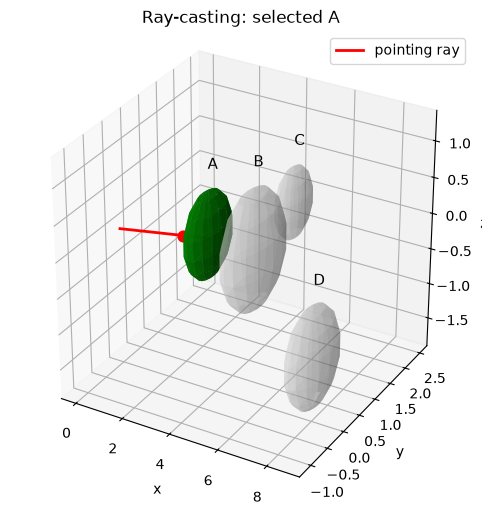

In [6]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
u, v = np.mgrid[0:2*np.pi:16j, 0:np.pi:8j]
for nm, c, R in scene:
    xs = c[0] + R*np.cos(u)*np.sin(v); ys = c[1] + R*np.sin(u)*np.sin(v); zs = c[2] + R*np.cos(v)
    hit = (nm == name)
    ax.plot_surface(xs, ys, zs, color="green" if hit else "lightgray",
                    alpha=0.9 if hit else 0.35)
    ax.text(c[0], c[1], c[2]+R+0.3, nm, fontsize=11)
L = t if t is not None else 9.0
line = ray_o[:, None] + ray_d[:, None]*np.linspace(0, L+1, 2)
ax.plot(line[0], line[1], line[2], "r-", lw=2, label="pointing ray")
if t is not None:
    hit_pt = ray_o + ray_d*t
    ax.scatter(*hit_pt, color="red", s=60)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title(f"Ray-casting: selected {name}"); ax.legend()
try:
    ax.set_box_aspect((1, 1, 1))
except Exception:
    pass
plt.show()


## Conclusion

You have built the two geometric foundations of every 3DUI:
- **homogeneous transformations** (chainable, invertible in closed form),
- **ray-casting selection** (the ray-sphere intersection + the nearest hit).

That was the *ideal* world: no noise, objects hit perfectly. In the **medium project** reality is
added — **hand tremor** makes the pointing direction noisy, and you will see that **distant, small
targets** are dramatically harder to hit (the angular Fitts' law) and how **Go-Go** saves the
reach. The **final project** then compares entire selection techniques under realistic clutter.
